In [1]:
import math
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# 1. Вариационный ряд

In [2]:
data = [3.0, 5.0, 4.0, 3.0, 3.0, 3.0, 2.0, 3.0, 3.0, 3.0, 3.0, 2.0, 4.0, 0.0, 3.0, 3.0, 3.0,
        3.0, 1.0, 2.0, 3.0, 3.0, 2.0, 2.0, 5.0, 2.0, 4.0, 4.0, 1.0, 2.0, 3.0, 1.0, 4.0, 0.0,
        3.0, 5.0, 6.0, 4.0, 8.0, 2.0, 2.0, 5.0, 1.0, 0.0, 1.0, 5.0, 3.0, 2.0, 5.0, 1.0]

variational_series = sorted(data)
print(variational_series)

[0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 6.0, 8.0]


# 2. Построение интервального статистического ряда

In [3]:
n = len(data)
k = round(1 + 3.322 * math.log10(n))
h = (max(data) - min(data)) / k

bins = [min(data) + i * h for i in range(k + 1)]

freq, intervals = np.histogram(data, bins=bins)

interval_series = []
for i in range(len(freq)):
    lower = intervals[i]
    upper = intervals[i + 1]
    interval_series.append((f"{lower:.2f} - {upper:.2f}", freq[i]))

print("Интервальный статистический ряд:")
print("Интервал\tЧacтoтa")
for interval, count in interval_series:
    print(f"{interval}\t{count}")

Интервальный статистический ряд:
Интервал	Чacтoтa
0.00 - 1.14	9
1.14 - 2.29	10
2.29 - 3.43	17
3.43 - 4.57	6
4.57 - 5.71	6
5.71 - 6.86	1
6.86 - 8.00	1


# 3. Построение полигона

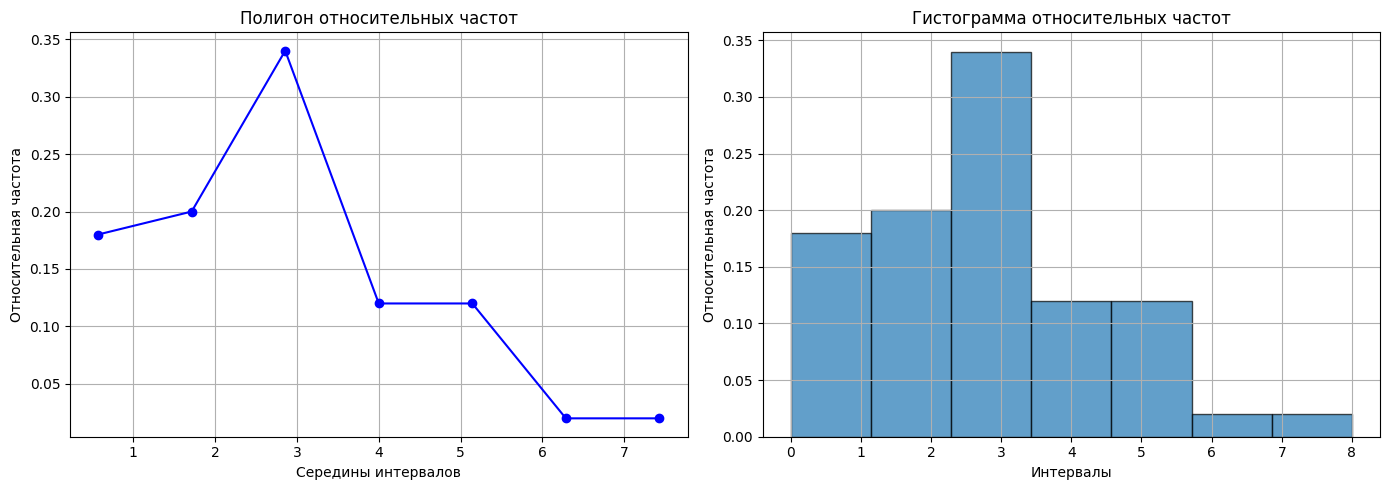

In [4]:
bins = np.linspace(min(data), max(data), k + 1)
freq, _ = np.histogram(data, bins=bins)
rel_freq = freq / n

midpoints = (bins[:-1] + bins[1:]) / 2

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Полигон
ax1.plot(midpoints, rel_freq, 'bo-', label='Полигон')
ax1.set_title('Полигон относительных частот')
ax1.set_xlabel('Середины интервалов')
ax1.set_ylabel('Относительная частота')
ax1.grid()

# Гистограмма
ax2.bar(bins[:-1], rel_freq, width=h, edgecolor='black', alpha=0.7, align='edge')
ax2.set_title('Гистограмма относительных частот')
ax2.set_xlabel('Интервалы')
ax2.set_ylabel('Относительная частота')
ax2.grid()

plt.tight_layout()
plt.show()

# 4. Эмпирическая функция распределения

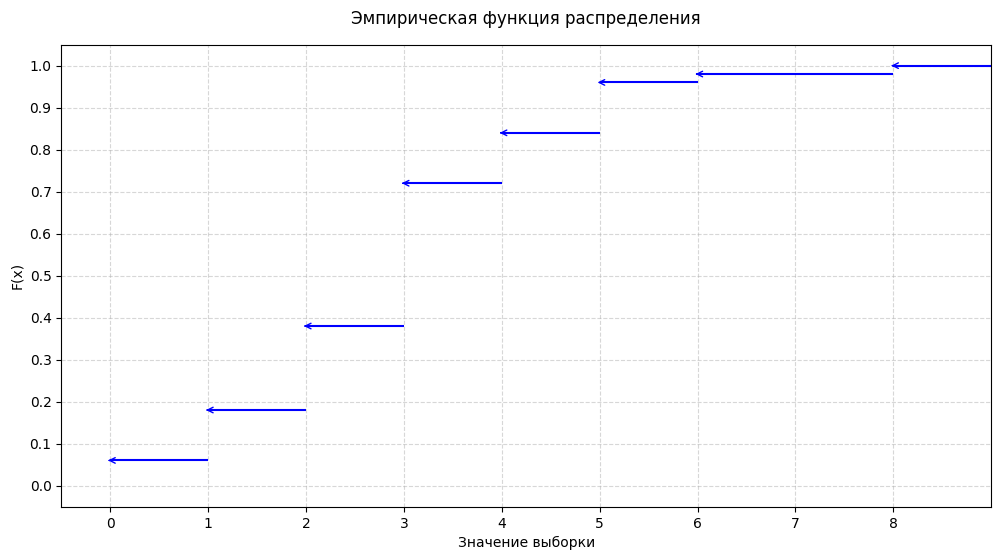

In [5]:
sorted_data = np.sort(data)
n = len(sorted_data)

unique_vals, counts = np.unique(sorted_data, return_counts=True)
cum_counts = np.cumsum(counts)
y = cum_counts / n

plt.figure(figsize=(12, 6))

for i in range(len(unique_vals)):
    start_x = unique_vals[i]

    if i < len(unique_vals) - 1:
        end_x = unique_vals[i + 1]
    else:
        end_x = unique_vals[-1] + 1

    plt.hlines(y=y[i], xmin=start_x, xmax=end_x, color='blue', linewidth=1.5)

    plt.annotate('', 
                 xy=(start_x, y[i]), 
                 xytext=(start_x - 0.05, y[i]),
                 arrowprops=dict(arrowstyle='<-', color='blue', lw=1))

plt.title('Эмпирическая функция распределения', pad=15)
plt.xlabel('Значение выборки')
plt.ylabel('F(x)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(np.arange(np.floor(min(data)), np.ceil(max(data)) + 1))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.xlim(unique_vals[0] - 0.5, unique_vals[-1] + 1)
plt.ylim(-0.05, 1.05)
plt.show()

# 5. Числовые характеричтики распределения

In [6]:
mean = np.mean(data)
var = np.var(data, ddof=1)
mode = stats.mode(data)
median = np.median(data)
skewness = stats.skew(data)
kurtosis = stats.kurtosis(data, fisher=True)
print(f"1. Выборочное среднее: {np.mean(data):.4f}")
print(f"2. Исправленная выборочная дисперсия: {np.var(data, ddof=1):.4f}")
print(f"3. Мода: {stats.mode(data).mode} (встречается {stats.mode(data).count} раз)")
print(f"4. Медиана: {np.median(data):.1f}")
print(f"5. Коэффициент асимметрии: {stats.skew(data):.4f}")
print(f"6. Коэффициент эксцесса: {stats.kurtosis(data, fisher=True):.4f}")

1. Выборочное среднее: 2.9000
2. Исправленная выборочная дисперсия: 2.5408
3. Мода: 3.0 (встречается 17 раз)
4. Медиана: 3.0
5. Коэффициент асимметрии: 0.5314
6. Коэффициент эксцесса: 0.8428


# 6. Гипотеза о распределении

# 7. Оценки параметров предполагаемого распределения генеральной совокупности

# 8. Построить на чертеже гистограммы и эмпирической функции её теоретические аналоги f(x) и F(x)

# 9. Проверка правила «трех сигм»

# 10. Критерий согласия Пирсона

# 11. Доверительные интервалы

In [7]:
import numpy as np
from scipy import stats

data = np.array([3.0, 5.0, 4.0, 3.0, 3.0, 3.0, 2.0, 3.0, 3.0, 3.0, 3.0, 2.0, 
                 4.0, 0.0, 3.0, 3.0, 3.0, 3.0, 1.0, 2.0, 3.0, 3.0, 2.0, 2.0, 
                 5.0, 2.0, 4.0, 4.0, 1.0, 2.0, 3.0, 1.0, 4.0, 0.0, 3.0, 5.0, 
                 6.0, 4.0, 8.0, 2.0, 2.0, 5.0, 1.0, 0.0, 1.0, 5.0, 3.0, 2.0, 
                 5.0, 1.0])
n = len(data)

mu_hat = np.mean(data)
sigma_hat = np.std(data, ddof=1)

print(f"Оценка μ: {mu_hat:.4f}")
print(f"Оценка σ: {sigma_hat:.4f}")

Оценка μ: 2.9000
Оценка σ: 1.5940


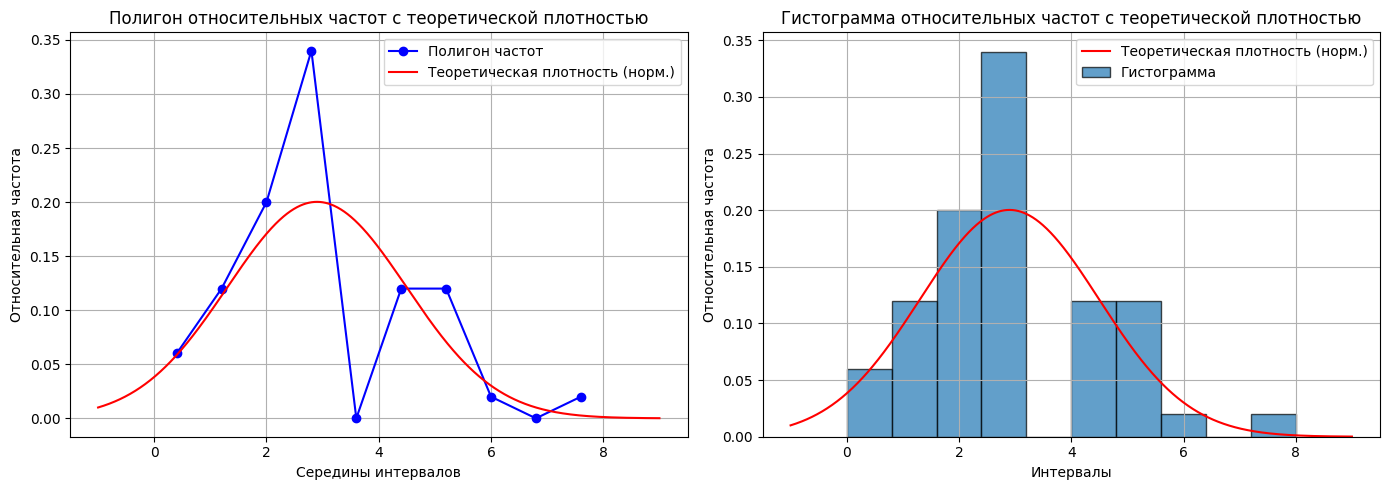

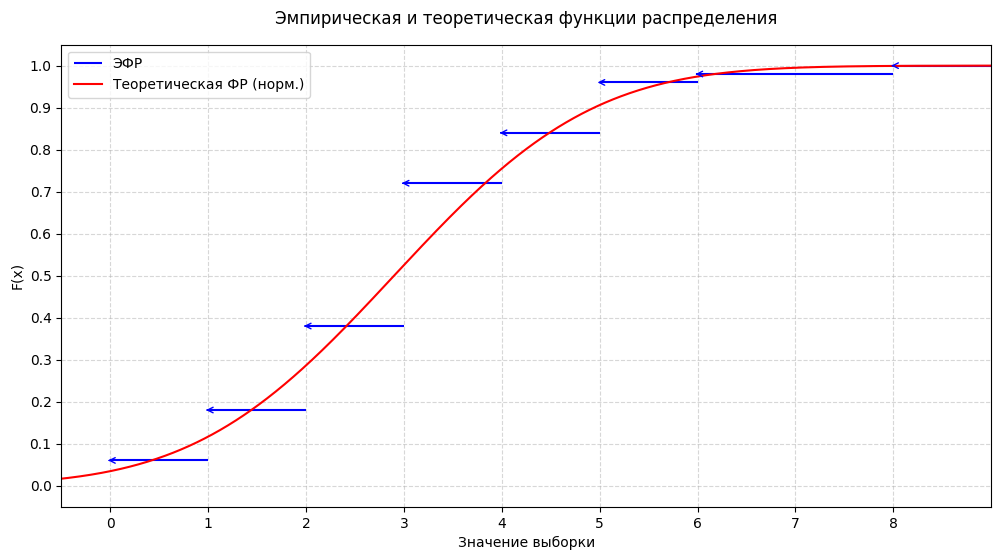

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Данные
data = np.array([3.0, 5.0, 4.0, 3.0, 3.0, 3.0, 2.0, 3.0, 3.0, 3.0, 3.0, 2.0, 
                 4.0, 0.0, 3.0, 3.0, 3.0, 3.0, 1.0, 2.0, 3.0, 3.0, 2.0, 2.0, 
                 5.0, 2.0, 4.0, 4.0, 1.0, 2.0, 3.0, 1.0, 4.0, 0.0, 3.0, 5.0, 
                 6.0, 4.0, 8.0, 2.0, 2.0, 5.0, 1.0, 0.0, 1.0, 5.0, 3.0, 2.0, 
                 5.0, 1.0])
n = len(data)

# Оценки параметров нормального распределения
mu_hat = np.mean(data)
sigma_hat = np.std(data, ddof=1)

# Гистограмма и полигон
k = 10  # Количество интервалов
h = (max(data) - min(data)) / k  # Ширина интервала
bins = np.linspace(min(data), max(data), k + 1)
freq, _ = np.histogram(data, bins=bins)
rel_freq = freq / n
midpoints = (bins[:-1] + bins[1:]) / 2

# Теоретическая плотность для нормального распределения
x_vals = np.linspace(min(data)-1, max(data)+1, 1000)
pdf_vals = stats.norm.pdf(x_vals, mu_hat, sigma_hat)

# Построение графиков
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Полигон с теоретической плотностью
ax1.plot(midpoints, rel_freq, 'bo-', label='Полигон частот')
ax1.plot(x_vals, pdf_vals*h, 'r-', label='Теоретическая плотность (норм.)')
ax1.set_title('Полигон относительных частот с теоретической плотностью')
ax1.set_xlabel('Середины интервалов')
ax1.set_ylabel('Относительная частота')
ax1.legend()
ax1.grid()

# Гистограмма с теоретической плотностью
ax2.bar(bins[:-1], rel_freq, width=h, edgecolor='black', alpha=0.7, align='edge', label='Гистограмма')
ax2.plot(x_vals, pdf_vals*h, 'r-', label='Теоретическая плотность (норм.)')
ax2.set_title('Гистограмма относительных частот с теоретической плотностью')
ax2.set_xlabel('Интервалы')
ax2.set_ylabel('Относительная частота')
ax2.legend()
ax2.grid()

plt.tight_layout()
plt.show()

# Эмпирическая функция распределения с теоретической
sorted_data = np.sort(data)
unique_vals, counts = np.unique(sorted_data, return_counts=True)
cum_counts = np.cumsum(counts)
y = cum_counts / n

# Теоретическая функция распределения
x_vals_ecdf = np.linspace(min(data)-1, max(data)+1, 1000)
cdf_vals = stats.norm.cdf(x_vals_ecdf, mu_hat, sigma_hat)

plt.figure(figsize=(12, 6))

# ЭФР
for i in range(len(unique_vals)):
    start_x = unique_vals[i]
    if i < len(unique_vals) - 1:
        end_x = unique_vals[i + 1]
    else:
        end_x = unique_vals[-1] + 1
    plt.hlines(y=y[i], xmin=start_x, xmax=end_x, color='blue', linewidth=1.5, label='ЭФР' if i == 0 else "")
    plt.annotate('', xy=(start_x, y[i]), xytext=(start_x - 0.05, y[i]),
                 arrowprops=dict(arrowstyle='<-', color='blue', lw=1))

# Теоретическая ФР
plt.plot(x_vals_ecdf, cdf_vals, 'r-', label='Теоретическая ФР (норм.)')

plt.title('Эмпирическая и теоретическая функции распределения', pad=15)
plt.xlabel('Значение выборки')
plt.ylabel('F(x)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(np.arange(np.floor(min(data)), np.ceil(max(data)) + 1))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.xlim(unique_vals[0] - 0.5, unique_vals[-1] + 1)
plt.ylim(-0.05, 1.05)
plt.legend()
plt.show()

In [9]:
within_1sigma = np.sum((data >= mu_hat - sigma_hat) & (data <= mu_hat + sigma_hat)) / n * 100
within_2sigma = np.sum((data >= mu_hat - 2*sigma_hat) & (data <= mu_hat + 2*sigma_hat)) / n * 100
within_3sigma = np.sum((data >= mu_hat - 3*sigma_hat) & (data <= mu_hat + 3*sigma_hat)) / n * 100

print(f"Данных в μ ± σ: {within_1sigma:.1f}% (ожидается ~68%)")
print(f"Данных в μ ± 2σ: {within_2sigma:.1f}% (ожидается ~95%)")
print(f"Данных в μ ± 3σ: {within_3sigma:.1f}% (ожидается ~99.7%)")

Данных в μ ± σ: 66.0% (ожидается ~68%)
Данных в μ ± 2σ: 98.0% (ожидается ~95%)
Данных в μ ± 3σ: 98.0% (ожидается ~99.7%)


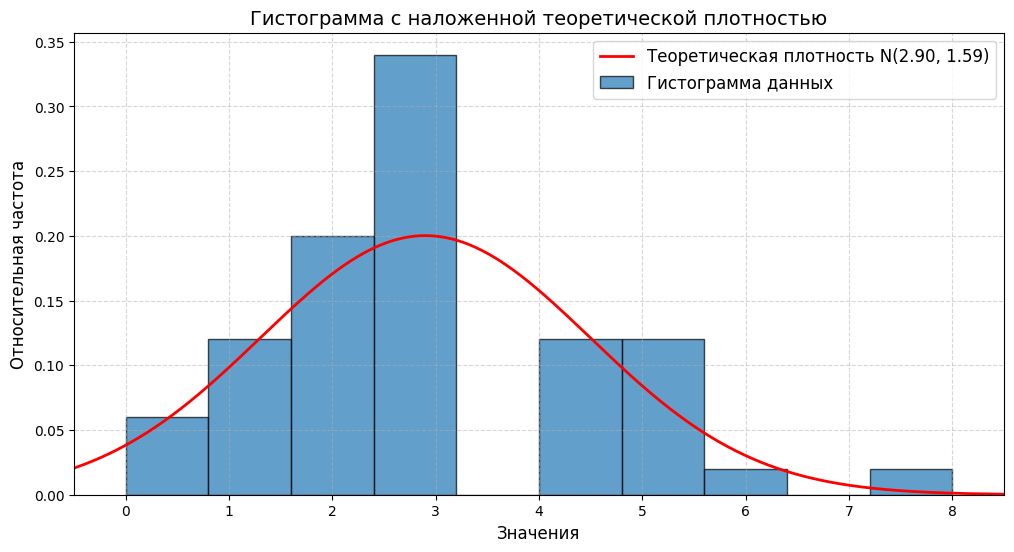

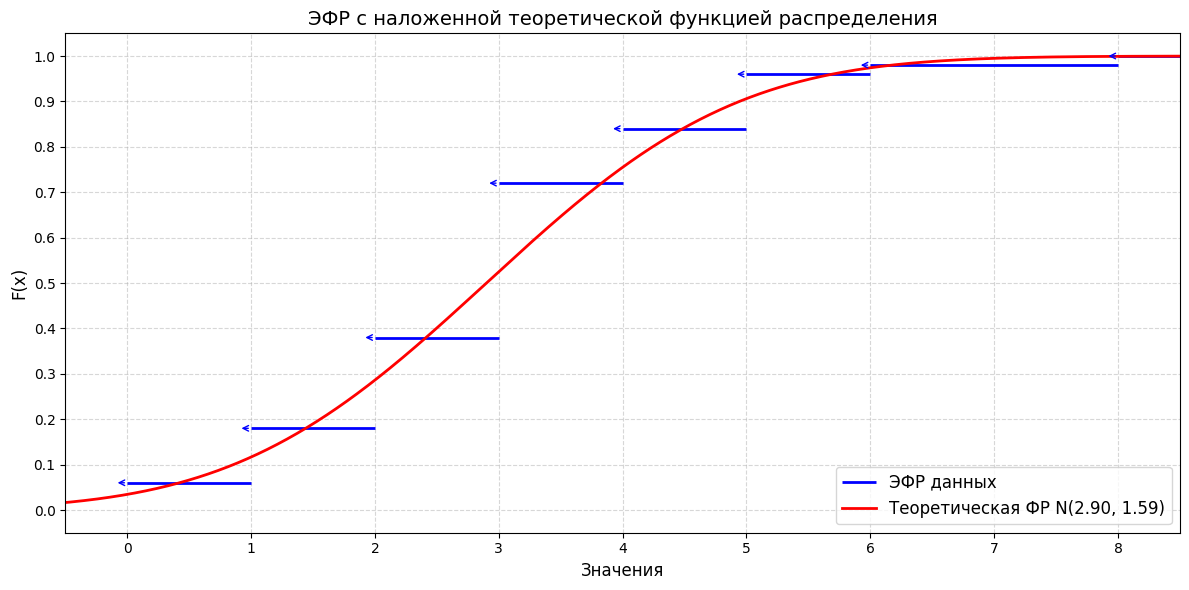

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Ваши данные
data = np.array([3.0, 5.0, 4.0, 3.0, 3.0, 3.0, 2.0, 3.0, 3.0, 3.0, 3.0, 2.0, 
                 4.0, 0.0, 3.0, 3.0, 3.0, 3.0, 1.0, 2.0, 3.0, 3.0, 2.0, 2.0, 
                 5.0, 2.0, 4.0, 4.0, 1.0, 2.0, 3.0, 1.0, 4.0, 0.0, 3.0, 5.0, 
                 6.0, 4.0, 8.0, 2.0, 2.0, 5.0, 1.0, 0.0, 1.0, 5.0, 3.0, 2.0, 
                 5.0, 1.0])
n = len(data)

# Оценки параметров нормального распределения
mu_hat = np.mean(data)
sigma_hat = np.std(data, ddof=1)

# =============================================
# 1. ГИСТОГРАММА + ТЕОРЕТИЧЕСКАЯ ПЛОТНОСТЬ
# =============================================
plt.figure(figsize=(12, 6))

# Ваш код для гистограммы (с небольшими изменениями)
k = 10
h = (max(data) - min(data)) / k
bins = np.linspace(min(data), max(data), k + 1)
freq, _ = np.histogram(data, bins=bins)
rel_freq = freq / n

# Ваша гистограмма
plt.bar(bins[:-1], rel_freq, width=h, edgecolor='black', 
        alpha=0.7, align='edge', label='Гистограмма данных')

# Теоретическая плотность нормального распределения
x = np.linspace(min(data)-1, max(data)+1, 1000)
pdf = stats.norm.pdf(x, mu_hat, sigma_hat) * h  # Масштабируем для соответствия гистограмме
plt.plot(x, pdf, 'r-', linewidth=2, label='Теоретическая плотность N(%.2f, %.2f)' % (mu_hat, sigma_hat))

plt.title('Гистограмма с наложенной теоретической плотностью', fontsize=14)
plt.xlabel('Значения', fontsize=12)
plt.ylabel('Относительная частота', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(np.arange(min(data), max(data)+1))
plt.xlim(min(data)-0.5, max(data)+0.5)

# =============================================
# 2. ЭФР + ТЕОРЕТИЧЕСКАЯ ФУНКЦИЯ РАСПРЕДЕЛЕНИЯ
# =============================================
plt.figure(figsize=(12, 6))

# Ваш код для ЭФР (с небольшими изменениями)
sorted_data = np.sort(data)
unique_vals, counts = np.unique(sorted_data, return_counts=True)
cum_counts = np.cumsum(counts)
y = cum_counts / n

# Ваша ЭФР
for i in range(len(unique_vals)):
    start_x = unique_vals[i]
    end_x = unique_vals[i+1] if i < len(unique_vals)-1 else unique_vals[-1]+1
    plt.hlines(y=y[i], xmin=start_x, xmax=end_x, color='blue', linewidth=2, 
               label='ЭФР данных' if i == 0 else "")
    plt.annotate('', xy=(start_x, y[i]), xytext=(start_x-0.1, y[i]),
                 arrowprops=dict(arrowstyle='<-', color='blue', lw=1))

# Теоретическая функция распределения
x = np.linspace(min(data)-1, max(data)+1, 1000)
cdf = stats.norm.cdf(x, mu_hat, sigma_hat)
plt.plot(x, cdf, 'r-', linewidth=2, label='Теоретическая ФР N(%.2f, %.2f)' % (mu_hat, sigma_hat))

plt.title('ЭФР с наложенной теоретической функцией распределения', fontsize=14)
plt.xlabel('Значения', fontsize=12)
plt.ylabel('F(x)', fontsize=12)
plt.legend(fontsize=12, loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(np.arange(min(data), max(data)+1))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.xlim(min(data)-0.5, max(data)+0.5)
plt.ylim(-0.05, 1.05)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from scipy import stats
data = np.array([3.0, 5.0, 4.0, 3.0, 3.0, 3.0, 2.0, 3.0, 3.0, 3.0, 3.0, 2.0, 
                 4.0, 0.0, 3.0, 3.0, 3.0, 3.0, 1.0, 2.0, 3.0, 3.0, 2.0, 2.0, 
                 5.0, 2.0, 4.0, 4.0, 1.0, 2.0, 3.0, 1.0, 4.0, 0.0, 3.0, 5.0, 
                 6.0, 4.0, 8.0, 2.0, 2.0, 5.0, 1.0, 0.0, 1.0, 5.0, 3.0, 2.0, 
                 5.0, 1.0])
n = len(data)
alpha = 0.05
mu_hat = np.mean(data)
sigma_hat = np.std(data, ddof=1)
def auto_bins(data):
    k = int(1 + 3.322 * np.log10(n))
    bins = np.linspace(min(data), max(data), k)

    while True:
        observed, _ = np.histogram(data, bins=bins)
        expected = n * np.diff(stats.norm.cdf(bins, mu_hat, sigma_hat))
        to_merge = np.where(expected < 5)[0]
        if len(to_merge) == 0:
            return observed, bins
        merge_idx = to_merge[0]
        if merge_idx == 0:
            bins = np.delete(bins, merge_idx + 1)
        else:
            bins = np.delete(bins, merge_idx)

observed, bins = auto_bins(data)
k = len(observed)
expected = n * np.diff(stats.norm.cdf(bins, mu_hat, sigma_hat))
chi2_stat = np.sum((observed - expected)**2 / expected)
df = k - 3
critical_value_chi2 = stats.chi2.ppf(1 - alpha, df)
p_value_chi2 = 1 - stats.chi2.cdf(chi2_stat, df)
sorted_data = np.sort(data)
ecdf = np.arange(1, n+1) / n
theoretical_cdf = stats.norm.cdf(sorted_data, mu_hat, sigma_hat)
Dn = np.max(np.abs(ecdf - theoretical_cdf))
critical_value_ks = stats.kstwo.ppf(1 - alpha, n)
p_value_ks = stats.kstest(data, 'norm', args=(mu_hat, sigma_hat)).pvalue

# Вывод оценок параметров
print(f"Оценки параметров:\nμ = {mu_hat:.4f}, σ = {sigma_hat:.4f}\n")

# Таблица для критерия Пирсона
print("\nТаблица для критерия Пирсона:")
print("Интервал     | Наблюдаемая | Ожидаемая   | (O-E)^2/E")
print("----------------------------------------------------")
for i in range(len(observed)):
    left = bins[i]
    right = bins[i+1]
    contribution = (observed[i] - expected[i])**2 / expected[i]
    print(f"[{left:4.1f}, {right:4.1f}) |  {observed[i]:10d} |  {expected[i]:10.2f} | {contribution:8.4f}")
print("Критерий Пирсона:")
print(f"χ² = {chi2_stat:.4f} (критическое = {critical_value_chi2:.4f})")
print(f"p-value = {p_value_chi2:.4f}\n")

# Таблица для критерия Колмогорова-Смирнова
max_diff_idx = np.argmax(np.abs(ecdf - theoretical_cdf))
print("\n\nТаблица для критерия Колмогорова-Смирнова (точка максимального расхождения):")
print("Значение | ЭФР     | Теоретическая ФР | Разница")
print("------------------------------------------------")
print(f" {sorted_data[max_diff_idx]:7.2f} | {ecdf[max_diff_idx]:7.4f} |  {theoretical_cdf[max_diff_idx]:15.4f} | {Dn:.4f}")

# Итоговые значения
print("\nИтог:")
print(f"Статистика Dn = {Dn:.4f}")
print(f"Критическое значение (α={alpha}, n={n}) = {critical_value_ks:.4f}")
print(f"p-value = {p_value_ks:.4f}")

Оценки параметров:
μ = 2.9000, σ = 1.5940


Таблица для критерия Пирсона:
Интервал     | Наблюдаемая | Ожидаемая   | (O-E)^2/E
----------------------------------------------------
[ 0.0,  1.6) |           9 |        8.65 |   0.0144
[ 1.6,  3.2) |          27 |       18.36 |   4.0620
[ 3.2,  4.8) |           6 |       15.44 |   5.7683
[ 4.8,  8.0) |           8 |        5.80 |   0.8369
Критерий Пирсона:
χ² = 10.6815 (критическое = 3.8415)
p-value = 0.0011



Таблица для критерия Колмогорова-Смирнова (точка максимального расхождения):
Значение | ЭФР     | Теоретическая ФР | Разница
------------------------------------------------
    3.00 |  0.7200 |           0.5250 | 0.1950

Итог:
Статистика Dn = 0.1950
Критическое значение (α=0.05, n=50) = 0.1884
p-value = 0.0386


In [12]:
gamma = 0.95
alpha = 1 - gamma

t_critical = stats.t.ppf(1 - alpha/2, df=n-1)
ci_mean = (mu_hat - t_critical * sigma_hat / np.sqrt(n), mu_hat + t_critical * sigma_hat / np.sqrt(n))

chi2_lower = stats.chi2.ppf(1 - alpha/2, df=n-1)
chi2_upper = stats.chi2.ppf(alpha/2, df=n-1)
ci_std = (np.sqrt((n-1) * sigma_hat**2 / chi2_lower), np.sqrt((n-1) * sigma_hat**2 / chi2_upper))

print(f"Доверительный интервал для μ (γ={gamma}): ({ci_mean[0]:.4f}; {ci_mean[1]:.4f})")
print(f"Доверительный интервал для σ (γ={gamma}): ({ci_std[0]:.4f}; {ci_std[1]:.4f})")

Доверительный интервал для μ (γ=0.95): (2.4470; 3.3530)
Доверительный интервал для σ (γ=0.95): (1.3315; 1.9863)
